In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import pickle
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

url="https://raw.githubusercontent.com/student-dheerajyadav/DataScience__45days/main/Used_Bikes.csv"
df=pd.read_csv(url)
df['owner'].value_counts()


,count
owner,
First Owner,29964
Second Owner,2564
Third Owner,108
Fourth Owner Or More,12


In [174]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  object 
 1   price       32648 non-null  float64
 2   city        32648 non-null  object 
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  object 
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.0+ MB


In [176]:
df['owner'].value_counts()

,count
owner,
First Owner,29964
Second Owner,2564
Third Owner,108
Fourth Owner Or More,12


In [177]:
df.describe()

,price,kms_driven,age,power
count,3.264800e+04,32648.000000,32648.000000,32648.000000
mean,6.829542e+04,26344.625184,8.048211,213.511302
std,9.071860e+04,22208.527695,4.031700,134.428868
min,4.400000e+03,1.000000,1.000000,100.000000
25%,2.500000e+04,12000.000000,5.000000,150.000000
50%,4.300000e+04,20373.000000,7.000000,150.000000
75%,8.000000e+04,35000.000000,10.000000,220.000000
max,1.900000e+06,750000.000000,63.000000,1800.000000


In [178]:
df['brand'].value_counts()


,count
brand,
Bajaj,11213
Hero,6368
Royal Enfield,4178
Yamaha,3916
Honda,2108
Suzuki,1464
TVS,1247
KTM,1077
Harley-Davidson,737


In [179]:
ktm = df[df['brand']=='KTM']
ktm.head()


,bike_name,price,city,kms_driven,owner,age,power,brand
33,KTM RC 390cc,180000.0,Pune,17700.0,First Owner,4.0,390.0,KTM
35,KTM Duke 200cc,70000.0,Nashik,100000.0,Second Owner,8.0,200.0,KTM
39,KTM RC 200cc ABS,179000.0,Bangalore,3400.0,First Owner,2.0,200.0,KTM
65,KTM Duke 200cc,94700.0,Baripara,32700.0,First Owner,4.0,200.0,KTM
83,KTM Duke 250cc,130000.0,Gandhidham,17500.0,Second Owner,4.0,250.0,KTM


In [180]:
print(f"maximum price of ktm bike :- {ktm['price'].max()}")
ktm['owner'].value_counts()
# availibility of ktm bike

maximum price of ktm bike :- 860000.0


,count
owner,
First Owner,1040
Second Owner,29
Third Owner,8


**Analyse the data with group by property**

In [181]:
grouped=df.groupby(by='city')       # grouped the data by city columns
grouped.get_group('Ahmedabad')

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
26,Hero Super Splendor 125cc,20000.0,Ahmedabad,29305.0,First Owner,16.0,125.0,Hero
54,Bajaj Avenger 220cc,40000.0,Ahmedabad,64000.0,First Owner,7.0,220.0,Bajaj
56,Honda Dream Yuga 110cc,34500.0,Ahmedabad,17056.0,First Owner,5.0,110.0,Honda
168,Royal Enfield Classic 350cc,107000.0,Ahmedabad,17000.0,First Owner,4.0,350.0,Royal Enfield
...,...,...,...,...,...,...,...,...
32540,Suzuki Zeus 125cc,35000.0,Ahmedabad,11885.0,First Owner,12.0,125.0,Suzuki
32559,Suzuki Zeus 125cc,35000.0,Ahmedabad,11885.0,First Owner,12.0,125.0,Suzuki
32578,Suzuki Zeus 125cc,35000.0,Ahmedabad,11885.0,First Owner,12.0,125.0,Suzuki
32597,Suzuki Zeus 125cc,35000.0,Ahmedabad,11885.0,First Owner,12.0,125.0,Suzuki


In [182]:

f"bikes available in Delhi :- {grouped.get_group('Delhi').shape[0]}"

'bikes available in Delhi :- 7318'

**Dividing Data into 2 parts based on data type**

In [183]:
catigorical_data = df.select_dtypes(include='O')
catigorical_data.head()

,bike_name,city,owner,brand
0,TVS Star City Plus Dual Tone 110cc,Ahmedabad,First Owner,TVS
1,Royal Enfield Classic 350cc,Delhi,First Owner,Royal Enfield
2,Triumph Daytona 675R,Delhi,First Owner,Triumph
3,TVS Apache RTR 180cc,Bangalore,First Owner,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,Bangalore,First Owner,Yamaha


In [184]:
numerical_data = df.select_dtypes(exclude='O')
numerical_data.head()

,price,kms_driven,age,power
0,35000.0,17654.0,3.0,110.0
1,119900.0,11000.0,4.0,350.0
2,600000.0,110.0,8.0,675.0
3,65000.0,16329.0,4.0,180.0
4,80000.0,10000.0,3.0,150.0


In [185]:
numerical_data.describe()

,price,kms_driven,age,power
count,3.264800e+04,32648.000000,32648.000000,32648.000000
mean,6.829542e+04,26344.625184,8.048211,213.511302
std,9.071860e+04,22208.527695,4.031700,134.428868
min,4.400000e+03,1.000000,1.000000,100.000000
25%,2.500000e+04,12000.000000,5.000000,150.000000
50%,4.300000e+04,20373.000000,7.000000,150.000000
75%,8.000000e+04,35000.000000,10.000000,220.000000
max,1.900000e+06,750000.000000,63.000000,1800.000000


In [186]:
catigorical_data.describe()

,bike_name,city,owner,brand
count,32648,32648,32648,32648
unique,471,443,4,23
top,Bajaj Pulsar 150cc,Delhi,First Owner,Bajaj
freq,2776,7318,29964,11213


In [189]:
# to remove the "bike_name" feature
# df=df.drop('bike_name',axis=1)
df.head(2)

,price,city,kms_driven,owner,age,power,brand
0,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield


In [190]:
df

,price,city,kms_driven,owner,age,power,brand
0,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha
...,...,...,...,...,...,...,...
32643,39000.0,Delhi,22000.0,First Owner,4.0,100.0,Hero
32644,30000.0,Karnal,6639.0,First Owner,9.0,180.0,TVS
32645,60000.0,Delhi,20373.0,First Owner,6.0,220.0,Bajaj
32646,15600.0,Jaipur,84186.0,First Owner,16.0,125.0,Hero


**Data Visualation**

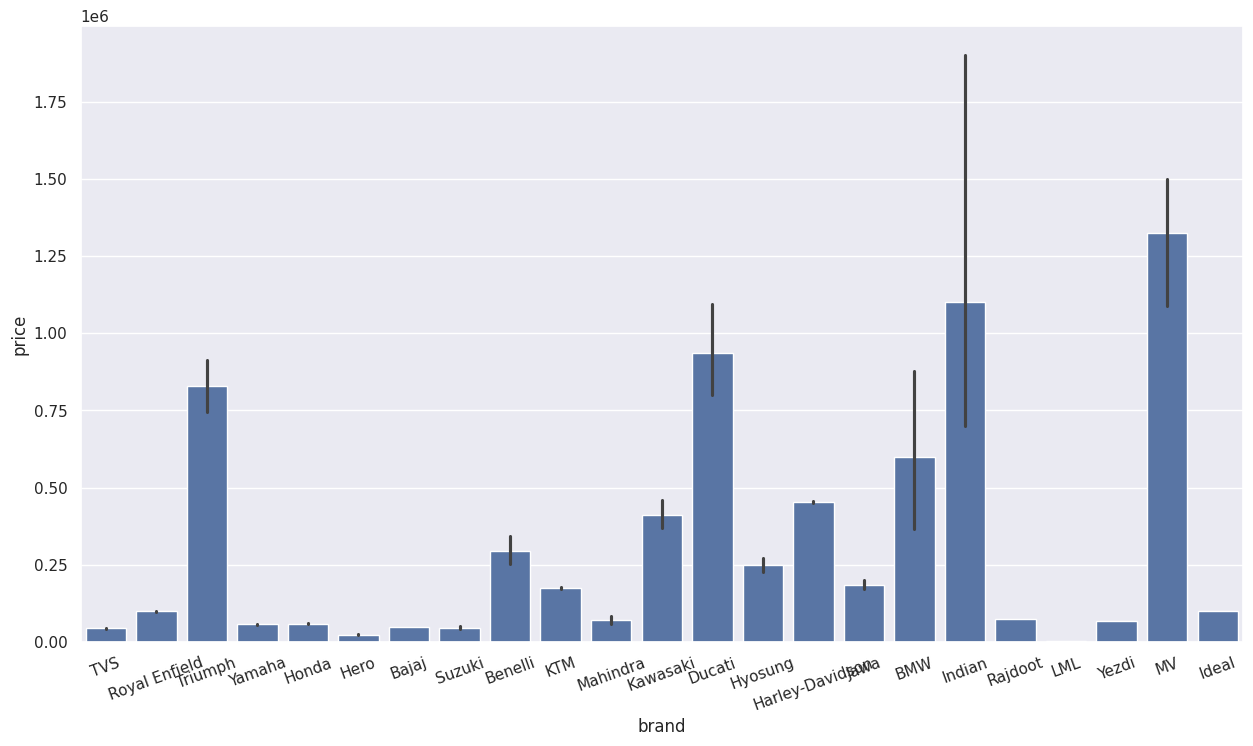

In [166]:
sns.set(rc={'figure.figsize':(15,8)})
sns.barplot(x=df['brand'],y=df['price'])
plt.xticks(rotation=20)
plt.show()

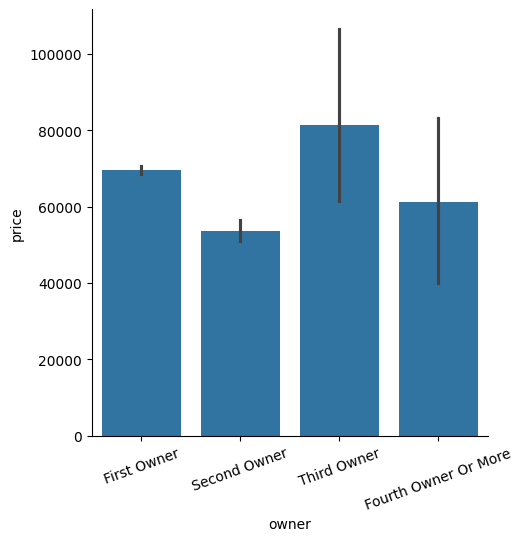

In [52]:
sns.catplot(x='owner',y='price',kind='bar',data=df)
plt.xticks(rotation=20)
plt.show()

<Axes: xlabel='owner', ylabel='count'>

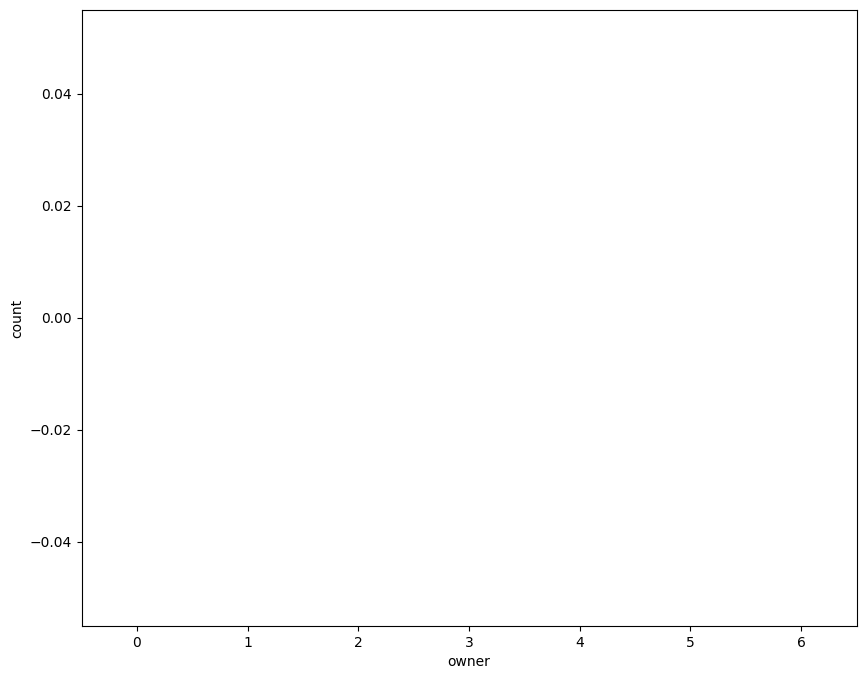

In [165]:
plt.figure(figsize=(10,8))
sns.countplot(x='owner',data=df.query("brand=='KTM'"))

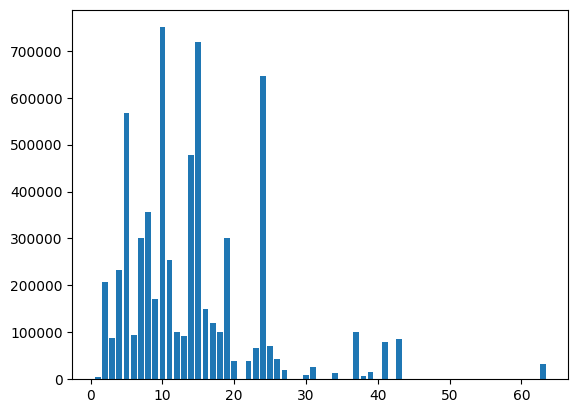

In [164]:
# sns.set(rc={'figure.figsize':(18,10)})
plt.bar(x=df['age'],height=df['kms_driven'])
plt.show()

In [191]:
df.dtypes

,0
price,float64
city,object
kms_driven,float64
owner,object
age,float64
power,float64
brand,object


In [192]:
dic={'First Owner':1,'Second Owner':2,'Third Owner':3,'Fourth Owner Or More':4}

df['owner']=df['owner'].map(dic)
df['owner'].value_counts()
df

,price,city,kms_driven,owner,age,power,brand
0,35000.0,Ahmedabad,17654.0,1,3.0,110.0,TVS
1,119900.0,Delhi,11000.0,1,4.0,350.0,Royal Enfield
2,600000.0,Delhi,110.0,1,8.0,675.0,Triumph
3,65000.0,Bangalore,16329.0,1,4.0,180.0,TVS
4,80000.0,Bangalore,10000.0,1,3.0,150.0,Yamaha
...,...,...,...,...,...,...,...
32643,39000.0,Delhi,22000.0,1,4.0,100.0,Hero
32644,30000.0,Karnal,6639.0,1,9.0,180.0,TVS
32645,60000.0,Delhi,20373.0,1,6.0,220.0,Bajaj
32646,15600.0,Jaipur,84186.0,1,16.0,125.0,Hero


In [193]:
city_name=['Delhi', 'Bangalore', 'Mumbai', 'Hyderabad', 'Pune', 'Chennai',
       'Lucknow', 'Jaipur', 'Ghaziabad', 'Ahmedabad', 'Noida', 'Bhopal',
       'Gautam Buddha Nagar', 'Kanchipuram', 'Jodhpur', 'Karnal', 'Allahabad',
       'Rupnagar', 'Gurgaon', 'Godhara', 'Faridabad', 'Perumbavoor', 'Kadapa',
       'Ludhiana', 'Kolkata', 'Thane', 'Jhansi', 'Vadodara', 'Surat',
       'Jalandhar', 'Chandigarh', 'Rajkot', 'Indore', 'Dehradun', 'Patna',
       'Navi Mumbai', 'Nagpur', 'Coimbatore', 'Guwahati', 'Tiruvallur',
       'Bhubaneshwar', 'Howrah', 'Kanpur', 'Aurangabad', 'Cuttack',
       'Visakhapatnam', 'Alibag', 'Alipore', 'Nashik', 'Ranchi', 'Kalyan',
       'Rohtak', 'Udaipur', 'Gorakhpur', 'Agra', 'Kota', '24 Pargana',
       'Meerut', 'Gandhinagar', 'Ernakulam']
maxc_ten_bike = df[df['city'].isin(city_name)]
maxc_ten_bike.head()
# these are all city data that having at least 10 bikes

,price,city,kms_driven,owner,age,power,brand
0,35000.0,Ahmedabad,17654.0,1,3.0,110.0,TVS
1,119900.0,Delhi,11000.0,1,4.0,350.0,Royal Enfield
2,600000.0,Delhi,110.0,1,8.0,675.0,Triumph
3,65000.0,Bangalore,16329.0,1,4.0,180.0,TVS
4,80000.0,Bangalore,10000.0,1,3.0,150.0,Yamaha


In [194]:
maxc_ten_bike['city'].value_counts().shape[0]              # total 60 city available in my data

60

In [195]:
# Filtering Data ...
bikes_name=df['brand'].value_counts()
most_available_bikes = bikes_name[bikes_name>10].keys()
greater_than_ten_bike = maxc_ten_bike[maxc_ten_bike['brand'].isin(most_available_bikes)]
greater_than_ten_bike.head()

,price,city,kms_driven,owner,age,power,brand
0,35000.0,Ahmedabad,17654.0,1,3.0,110.0,TVS
1,119900.0,Delhi,11000.0,1,4.0,350.0,Royal Enfield
2,600000.0,Delhi,110.0,1,8.0,675.0,Triumph
3,65000.0,Bangalore,16329.0,1,4.0,180.0,TVS
4,80000.0,Bangalore,10000.0,1,3.0,150.0,Yamaha


In [196]:
# bike brand labeling
bike_encoding_dict={'Bajaj':3, 'Hero':16, 'Royal Enfield':1, 'Yamaha':5, 'Honda':6, 'Suzuki':7, 'TVS':8,
       'KTM':2, 'Harley-Davidson':4, 'Kawasaki':9, 'Hyosung':10, 'Benelli':11, 'Mahindra':12,
       'Triumph':13, 'Ducati':14, 'BMW':15}
greater_than_ten_bike['brand']=greater_than_ten_bike['brand'].map(bike_encoding_dict)
greater_than_ten_bike.head()

,price,city,kms_driven,owner,age,power,brand
0,35000.0,Ahmedabad,17654.0,1,3.0,110.0,8
1,119900.0,Delhi,11000.0,1,4.0,350.0,1
2,600000.0,Delhi,110.0,1,8.0,675.0,13
3,65000.0,Bangalore,16329.0,1,4.0,180.0,8
4,80000.0,Bangalore,10000.0,1,3.0,150.0,5


In [197]:
df2 = greater_than_ten_bike
df2[df2['brand']==12].head()

,price,city,kms_driven,owner,age,power,brand
47,28000.0,Jaipur,45000.0,1,2.0,110.0,12
427,145000.0,Thane,16000.0,1,5.0,300.0,12
474,18999.0,Pune,38669.0,3,6.0,110.0,12
935,175000.0,Delhi,8000.0,1,3.0,300.0,12
946,115000.0,Gurgaon,35000.0,1,5.0,300.0,12


In [198]:
numerical_data.columns

Index(['price', 'kms_driven', 'age', 'power'], dtype='object')

**Data cleaning**

In [199]:
df['age']=df['age'].astype(int)
dic={'First Owner':1,'Second Owner':2,'Third Owner':3,'Fourth Owner Or More':4}

df['owner']=df['owner'].map(dic)
df['owner'].value_counts()
ser=df['city'].value_counts()
ser[ser>10].keys()

Index(['Delhi', 'Bangalore', 'Mumbai', 'Hyderabad', 'Pune', 'Chennai',
       'Lucknow', 'Jaipur', 'Ghaziabad', 'Ahmedabad', 'Noida', 'Bhopal',
       'Gautam Buddha Nagar', 'Kanchipuram', 'Jodhpur', 'Karnal', 'Rupnagar',
       'Allahabad', 'Gurgaon', 'Godhara', 'Faridabad', 'Perumbavoor', 'Kadapa',
       'Ludhiana', 'Kolkata', 'Thane', 'Jhansi', 'Vadodara', 'Surat',
       'Jalandhar', 'Chandigarh', 'Rajkot', 'Indore', 'Dehradun', 'Patna',
       'Nagpur', 'Navi Mumbai', 'Coimbatore', 'Tiruvallur', 'Guwahati',
       'Bhubaneshwar', 'Howrah', 'Kanpur', 'Aurangabad', 'Cuttack',
       'Visakhapatnam', 'Alibag', 'Alipore', 'Ranchi', 'Nashik', 'Kalyan',
       'Agra', 'Rohtak', 'Kota', 'Udaipur', 'Gorakhpur', 'Ernakulam',
       'Gandhinagar', 'Meerut', '24 Pargana'],
      dtype='object', name='city')

**TO check the correlation in between independent and dependent feature**

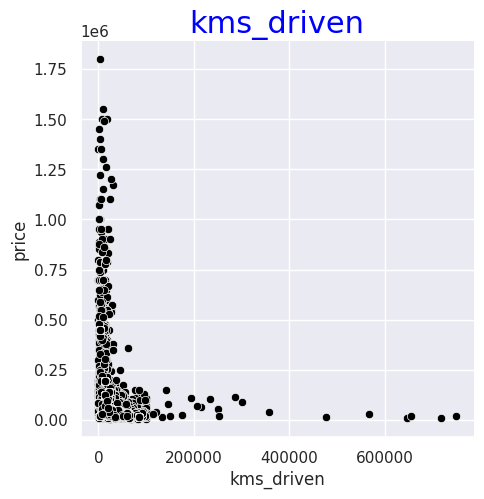

In [200]:
sns.relplot(x='kms_driven',y='price',data=df2,color='black')            #,hue='age',
plt.title('kms_driven',fontdict={'fontsize':22,'color':'blue'})
plt.show()

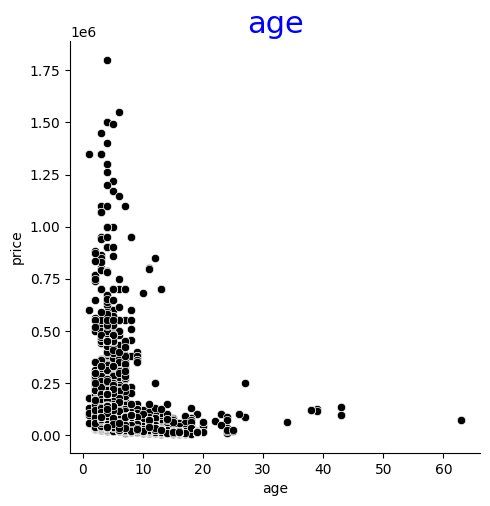

In [82]:
sns.relplot(x='age',y='price',data=df2,color='black')
plt.title('age',fontdict={'fontsize':22,'color':'blue'})
plt.show()

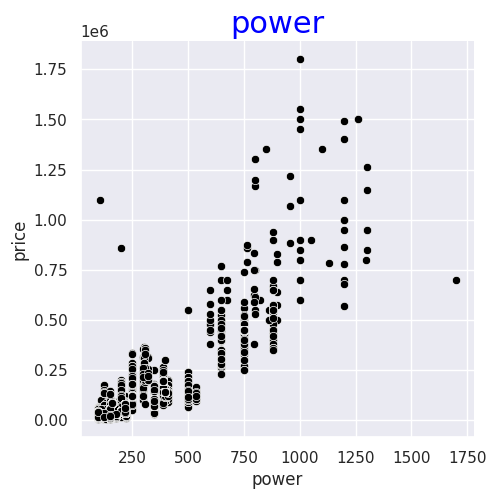

In [201]:


# positive relation
sns.relplot(x='power',y='price',data=df2,color='black')            #,hue='age',
plt.title('power',fontdict={'fontsize':22,'color':'blue'})
plt.show()

<Axes: >

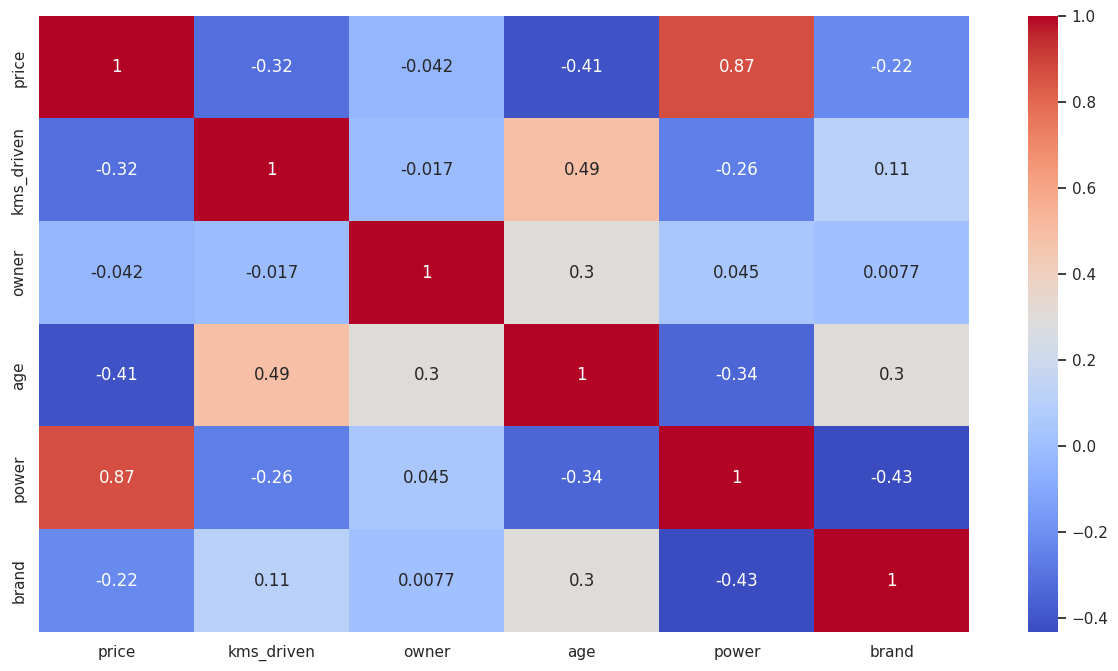

In [202]:
sns.heatmap(df2.select_dtypes(exclude='O').corr(),annot=True,cmap='coolwarm')
# checking corelation

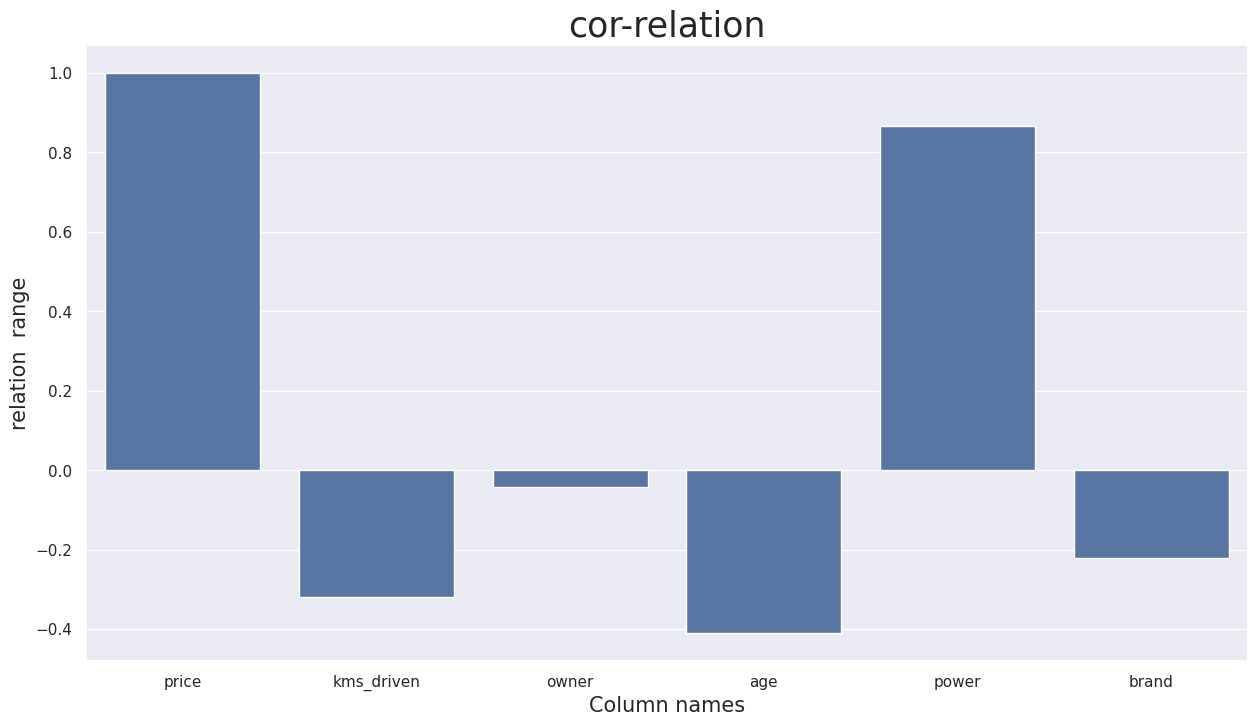

In [203]:
sns.barplot(x = df2.select_dtypes(exclude='O').corr()['price'].keys(),y=df2.select_dtypes(exclude='O').corr()['price'].values)
plt.title('cor-relation',size=25)
plt.xlabel('Column names',size=15)
plt.ylabel('relation  range',size=15)
plt.show()
# ploting the corelation

<Axes: xlabel='power', ylabel='power'>

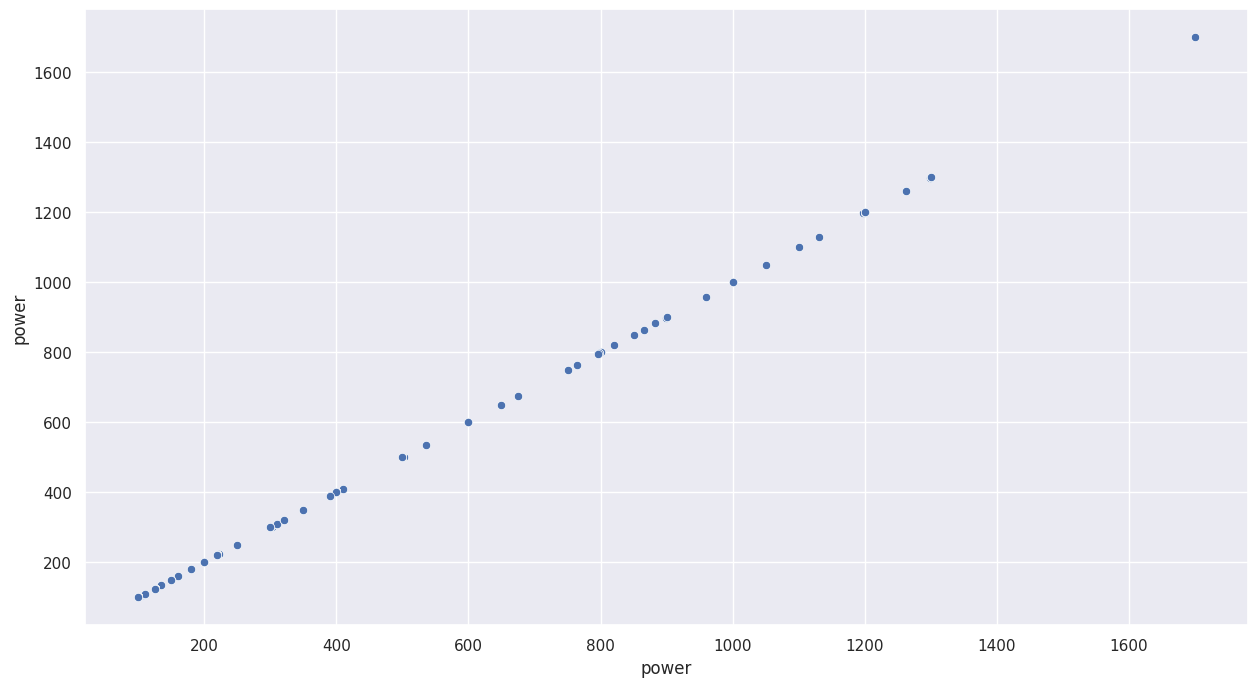

In [204]:
sns.scatterplot(x='power',y='power',data=df2)
# this is +1 relationship because, we plot relation in same columns

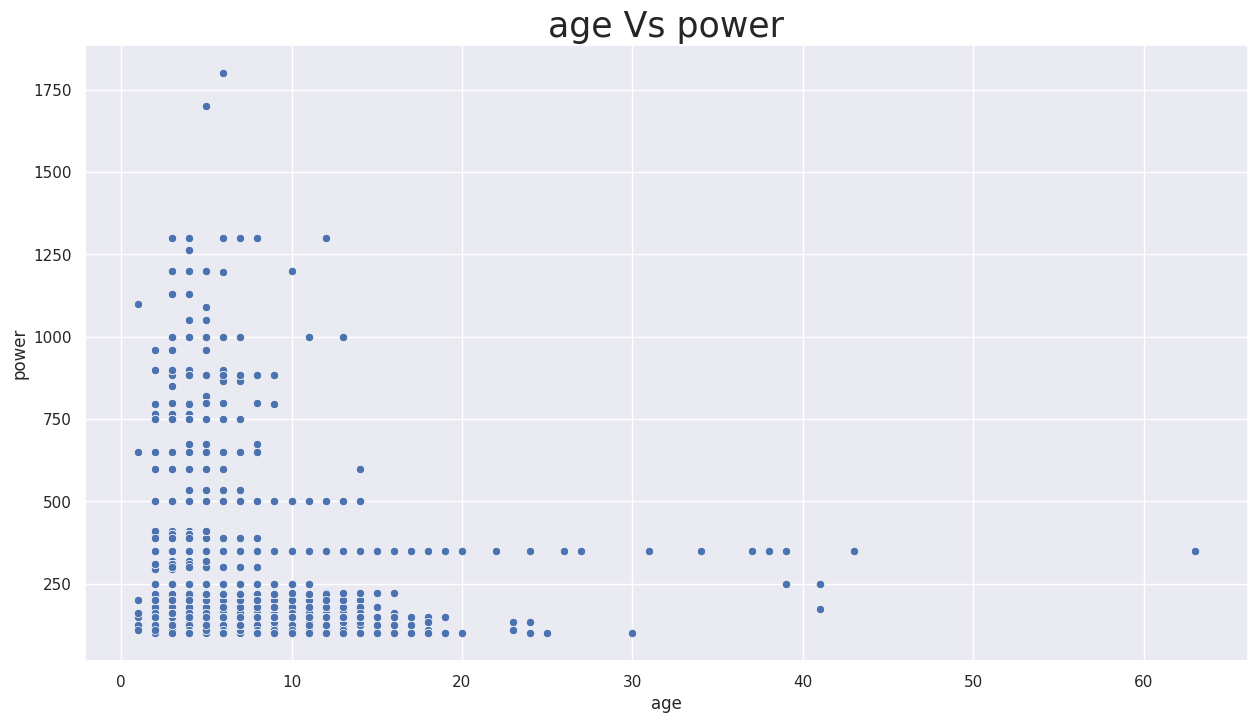

In [205]:
sns.scatterplot(x='age',y='power',data=df)
plt.title('age Vs power',size=25)
plt.show()

In [207]:
numerical_data = df2.select_dtypes(exclude='O')
categorical_data = df2.select_dtypes(include='O')

In [208]:
# from kms_driven feature
lower_limit = dict()
uper_limit = dict()

for colum in numerical_data.columns:
    q1,q3=df2[colum].quantile([.25,.75])   # 1st and 3rd quartile
    IQR=q3-q1        # calculating interquatile range
    LL=q1-(1.5*IQR)    # lower range
    UL=q3+(1.5*IQR)
    lower_limit[colum]=LL
    uper_limit[colum]=UL


In [213]:
df2 = df2.drop('city',axis=1)
df2.head(2)

,price,kms_driven,owner,age,power,brand
0,35000.0,17654.0,1,3.0,110.0,8
1,119900.0,11000.0,1,4.0,350.0,1


In [214]:
# df2 = df2.drop('city',axis=1)
df2.head(2)

,price,kms_driven,owner,age,power,brand
0,35000.0,17654.0,1,3.0,110.0,8
1,119900.0,11000.0,1,4.0,350.0,1


**Set the variable for ML model**

In [215]:
x = df2.drop('price',axis=1)
y = df2[['price']]
x.head(2)

,kms_driven,owner,age,power,brand
0,17654.0,1,3.0,110.0,8
1,11000.0,1,4.0,350.0,1


In [216]:

# Splitting the data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)

In [217]:
x_train

,kms_driven,owner,age,power,brand
14276,22697.0,1,7.0,125.0,7
31672,20245.0,2,11.0,220.0,3
9235,5400.0,1,8.0,350.0,1
13310,20000.0,1,4.0,350.0,1
11920,42837.0,1,8.0,150.0,6
...,...,...,...,...,...
30771,16336.0,1,7.0,350.0,1
6007,43000.0,1,9.0,100.0,16
979,98581.0,1,9.0,150.0,3
16764,18742.0,1,6.0,150.0,5


In [218]:
from sklearn.ensemble import  RandomForestRegressor
rdf = RandomForestRegressor()
rdf.fit(x_train,y_train)
# print("Training accuracy :- ",rdf.score(x_train,y_train))
# print("Testing accuracy :- ",rdf.score(x_test,y_test))


RandomForestRegressor()

In [219]:
print("Training accuracy :- ",rdf.score(x_train,y_train))
print("Testing accuracy :- ",rdf.score(x_test,y_test))

Training accuracy :-  0.9940538423682397
Testing accuracy :-  0.9834556357763701


In [220]:
import joblib
joblib.dump(rdf,'updated_model.lb')
loaded_model = joblib.load('updated_model.lb')

In [221]:
pred = rdf.predict(x_test)

In [222]:
compare = y_test
compare['prediction'] = pred
compare.columns = ['actual','prediction']
compare.iloc[0:20]

,actual,prediction
19840,15600.0,15600.00
27080,22000.0,22000.00
25866,43000.0,43000.00
12986,11900.0,11900.00
2239,160000.0,188021.00
3215,16000.0,14621.02
21009,25000.0,25000.00
11061,60000.0,60000.00
26663,45000.0,45000.00
4331,34000.0,32345.80


In [223]:
print(rdf.score(x_train,y_train))
print(rdf.score(x_test,y_test['actual']))

0.9940538423682397
0.9834556357763701
